In [1]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 


In [2]:
df= pd.read_csv('/Users/pranesh/coding2/MachineLearningFrom0/datasets/spotify_millsongdata.csv')

In [3]:
df.head(100)

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...
...,...,...,...,...
95,ABBA,The Name Of The Game,/a/abba/the+name+of+the+game_20002863.html,"I've seen you twice, in a short time \r\nOnly..."
96,ABBA,The Piper,/a/abba/the+piper_20002946.html,They came from the hills \r\nAnd they came fr...
97,ABBA,The Visitors,/a/abba/the+visitors_20002864.html,I hear the doorbell ring and suddenly the pani...
98,ABBA,The Way Old Friends Do,/a/abba/the+way+old+friends+do_20002573.html,You and I can share the silence \r\nFinding c...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [5]:
df.isnull().sum()

artist    0
song      0
link      0
text      0
dtype: int64

In [6]:
top_artists = df['artist'].value_counts().head(10)
print(top_artists)

artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Cher                187
Alabama             187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [7]:
df = df.sample(10000)

In [8]:
df = df.drop('link', axis = 1).reset_index(drop = True)

In [9]:
df

,artist,song,text
0,Elvis Presley,Guitar Man,"Well, I quit my job down at the car wash, \r\..."
1,Marianne Faithfull,Counting,Now is the glimmering spinning beginning \r\n...
2,Hank Williams Jr.,Fax Me A Beer,Well here we are smack in the middle of the 90...
3,Nick Cave,Muddy Water,"(J. Bundrick) \r\n \r\nMary, grab the baby, ..."
4,Vince Gill,Given More Time,"It's been a long day, Tell me how you've been ..."
...,...,...,...
9995,Kris Kristofferson,The Taker,"He's a giver, he'll give her \r\nThe kind of ..."
9996,Leonard Cohen,Famous Blue Raincoat,"It's four in the morning, the end of December ..."
9997,Vanessa Williams,Winter Weather,I love the winter weather \r\nSo the two of u...
9998,David Bowie,Dirty Boys,Something like Tobacco Road \r\nLiving on a l...


In [10]:
all_lyrics = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lyrics)

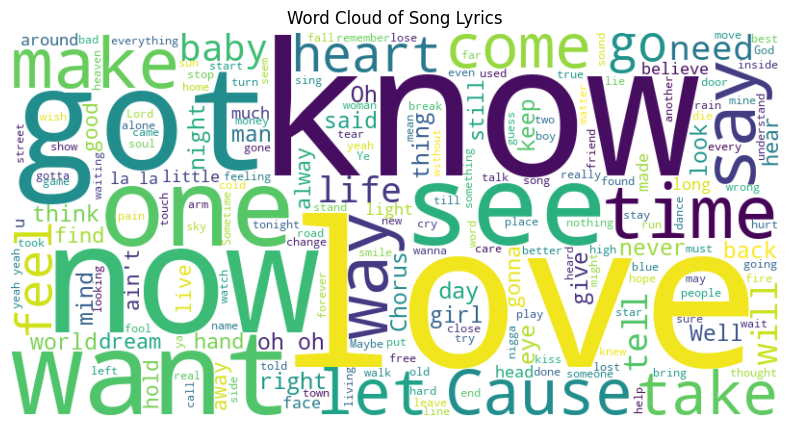

In [11]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Song Lyrics')
plt.show()


In [12]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/pranesh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pranesh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pranesh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
stop_words = set(stopwords.words('english'))

In [14]:
def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [15]:
df['cleaned_text'] = df['text'].apply(preprocess_text)


In [16]:
df["cleaned_text"]

0       well quit job car wash left mama goodbye note ...
1       glimmering spinning beginning something ive pr...
2       well smack middle high tech age got lasers cds...
3       j bundrick mary grab baby rivers rising muddy ...
4       long day tell youve sorry late go sitting toge...
                              ...                        
9995    hes giver hell give kind attention shes never ...
9996    four morning end december im writing see youre...
9997    love winter weather two us get together theres...
9998    something like tobacco road living lonely road...
9999    need know real cause ive known get wrong memor...
Name: cleaned_text, Length: 10000, dtype: object

In [17]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [18]:
cosine_sin = cosine_similarity(tfidf_matrix, tfidf_matrix) 

In [20]:
def recommend_songs(song_name, cosine_sin = cosine_sin, df = df , top_n = 5):
    idx = df[df['song'].str.lower() == song_name.lower()].index
    if len(idx) ==0:
        return "Song not found in the dataset."
    idx = idx[0]
    
    sin_scores = list(enumerate(cosine_sin[idx]))
    sin_scores = sorted(sin_scores ,key = lambda x: x[1], reverse = True)
    sin_scores = sin_scores[1: top_n + 1]   
    
    song_indices = [i[0] for i in sin_scores]
    return df['artist','song'].iloc[song_indices]

In [21]:
df["song"][2]

'Fax Me A Beer'

In [23]:
print("\nrecommend for the song 'Blinded By The Lights':")
recommendations = recommend_songs('christmas lights')
print(recommendations)


recommend for the song 'Blinded By The Lights':
Song not found in the dataset.
